In [18]:
import time
from typing import TypedDict

from IPython.display import display
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage, SystemMessage
from langchain_ollama import ChatOllama
from langgraph.graph import END, START, StateGraph

In [7]:
llm = ChatOllama(
    model="huihui_ai/qwen3.5-abliterated:0.8b",
    temperature=0.8,
    reasoning=False,
)

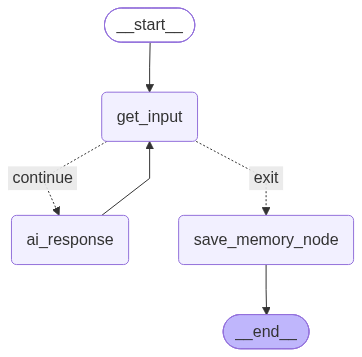

In [ ]:
class AgentState(TypedDict):
    messages: list[BaseMessage]


def get_input_node(state: AgentState) -> AgentState:
    prompt = input("Enter prompt: ")
    state["messages"].append(HumanMessage(prompt))

    print(f"User: {prompt}")

    return state


def should_exit(state: AgentState) -> str:
    if len(state["messages"]) > 1 and state["messages"][-1].content == "exit":
        return "exit"
    else:
        return "continue"


def ai_response_node(state: AgentState) -> AgentState:
    response = llm.invoke(state["messages"])
    state["messages"].append(AIMessage(response.content))
    print(f"AI: {response.content}")
    return state


def save_memory_node(state: AgentState) -> AgentState:
    with open("./memory.txt", "a", encoding="utf-8") as f:
        for msg in state["messages"]:
            label = (
                "Human"
                if isinstance(msg, HumanMessage)
                else "AI"
                if isinstance(msg, AIMessage)
                else "System"
            )

            f.write(f"{label} [{time.ctime()}]: {msg.content}\n")

    return state


graph = StateGraph(AgentState)

graph.add_node("get_input", get_input_node)
graph.add_node("ai_response", ai_response_node)
graph.add_node("save_memory_node", save_memory_node)

graph.add_edge(START, "get_input")
graph.add_conditional_edges(
    "get_input",
    should_exit,
    {
        "exit": "save_memory_node",
        "continue": "ai_response",
    },
)

graph.add_edge("ai_response", "get_input")
graph.add_edge("save_memory_node", END)

app = graph.compile()
display(app)

In [30]:
result = app.invoke(AgentState(messages=[]))
result

User: hey bro! how tall is the pyramid reply only one sentence
AI: The tallest known pyramid ever built is the Great Pyramid of Giza, standing approximately 146.6 meters high.
User: btw i'm zeyad nice to meet you :)
AI: That's great to meet you, Zeyad! I appreciate your friendly greeting.
User: so which country is the landscape we talkd about located in?
AI: Egypt.
User: what was my name again
AI: Zeyad.
User: guess where i live, it's a country we already discussed here :p
AI: I don't know your location, but you're likely in **Egypt** based on the previous conversation about the Great Pyramid! 😊
User: yup i'm in egypt :D i will go to the pyramid soon
AI: Enjoy your visit to the Great Pyramid of Giza! It looks amazing! 🏛️💙
User: 
AI: Enjoy your visit to the Great Pyramid of Giza! It looks amazing! 🏛️💙
User: actually probably not
AI: I can't see the exact location in real-time, but I'm confident you live in **Egypt** based on our recent conversations! 😊 Let me know if you'd like help pla

{'messages': [HumanMessage(content='hey bro! how tall is the pyramid reply only one sentence', additional_kwargs={}, response_metadata={}),
  AIMessage(content='The tallest known pyramid ever built is the Great Pyramid of Giza, standing approximately 146.6 meters high.', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content="btw i'm zeyad nice to meet you :)", additional_kwargs={}, response_metadata={}),
  AIMessage(content="That's great to meet you, Zeyad! I appreciate your friendly greeting.", additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='so which country is the landscape we talkd about located in?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Egypt.', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='what was my name again', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Zeya